In [1]:
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
df.duplicated().sum()

165

In [11]:
df = df.drop_duplicates()

df.shape

(32416, 12)

In [13]:
df[df["person_age"] > 80][["person_age", "person_income", "person_emp_length"]]

,person_age,person_income,person_emp_length
81,144,250000,4.0
183,144,200000,4.0
575,123,80004,2.0
747,123,78000,7.0
32297,144,6000000,12.0
32416,94,24000,1.0
32506,84,94800,2.0


In [15]:
df = df[(df["person_age"] >= 20) & (df["person_age"] <= 80)]

df.shape

(32409, 12)

In [17]:
df[df["person_emp_length"] > 50][["person_age", "person_emp_length", "person_income"]]

,person_age,person_emp_length,person_income
0,22,123.0,59000
210,21,123.0,192000


In [19]:
df = df[(df["person_emp_length"] >= 0) & (df["person_emp_length"] <= 50)]

df.shape

(31520, 12)

In [21]:
df = pd.read_csv("credit_risk_dataset.csv")

df = df.drop_duplicates()

df = df[(df["person_age"] >= 20) & (df["person_age"] <= 80)]

df = df[(df["person_emp_length"].isna()) | (df["person_emp_length"] <= 50)]

df.shape

(32407, 12)

In [23]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3093
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [25]:
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3093
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [27]:
df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [29]:
df.shape

(32407, 12)

In [31]:
df["loan_status"].value_counts()

loan_status
0    25319
1     7088
Name: count, dtype: int64

In [33]:
default_rate = df["loan_status"].mean() * 100

default_rate

21.871817817138272

In [35]:
df.groupby("loan_grade")["loan_status"].mean() * 100

loan_grade
A     9.961686
B    16.323190
C    20.761461
D    59.049461
E    64.485981
F    70.539419
G    98.437500
Name: loan_status, dtype: float64

In [37]:
df.groupby("loan_intent")["loan_status"].mean() * 100

loan_intent
DEBTCONSOLIDATION    28.676045
EDUCATION            17.256982
HOMEIMPROVEMENT      26.154702
MEDICAL              26.767092
PERSONAL             19.890810
VENTURE              14.861771
Name: loan_status, dtype: float64

In [39]:
df.groupby("person_home_ownership")["loan_status"].mean() * 100

person_home_ownership
MORTGAGE    12.622522
OTHER       31.132075
OWN          7.491221
RENT        31.613021
Name: loan_status, dtype: float64

In [41]:
df.groupby("cb_person_default_on_file")["loan_status"].mean() * 100

cb_person_default_on_file
N    18.438414
Y    37.860010
Name: loan_status, dtype: float64

In [43]:
df.groupby("loan_status")["loan_percent_income"].mean()

loan_status
0    0.148800
1    0.246858
Name: loan_percent_income, dtype: float64

In [45]:
df.groupby("loan_status")["person_income"].mean()

loan_status
0    70598.243572
1    49093.100451
Name: person_income, dtype: float64

In [47]:
df.groupby("loan_status")["loan_amnt"].mean()

loan_status
0     9239.414076
1    10854.073787
Name: loan_amnt, dtype: float64

In [51]:
df.groupby("loan_status")["loan_int_rate"].mean()

loan_status
0    10.492565
1    12.879454
Name: loan_int_rate, dtype: float64

In [53]:
df["age_group"] = pd.cut(
    df["person_age"],
    bins=[19, 25, 35, 45, 55, 80],
    labels=["20-25", "26-35", "36-45", "46-55", "56-80"]
)

df.groupby("age_group")["loan_status"].mean() * 100

C:\Users\lubna shireen\AppData\Local\Temp\ipykernel_1916\1435803945.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_status"].mean() * 100


age_group
20-25    23.131929
26-35    20.691416
36-45    20.683517
46-55    21.875000
56-80    24.242424
Name: loan_status, dtype: float64

In [55]:
df["income_group"] = pd.cut(
    df["person_income"],
    bins=[0, 30000, 60000, 100000, 200000, float("inf")],
    labels=["Below 30K", "30K-60K", "60K-100K", "100K-200K", "Above 200K"]
)

df.groupby("income_group", observed=True)["loan_status"].mean() * 100

income_group
Below 30K     45.596433
30K-60K       23.756632
60K-100K      13.385417
100K-200K      9.268162
Above 200K    11.963883
Name: loan_status, dtype: float64

In [57]:
df["loan_amount_group"] = pd.cut(
    df["loan_amnt"],
    bins=[0, 5000, 10000, 20000, 30000, 35000],
    labels=["Below 5K", "5K-10K", "10K-20K", "20K-30K", "30K-35K"]
)

df.groupby("loan_amount_group", observed=True)["loan_status"].mean() * 100

loan_amount_group
Below 5K    20.470938
5K-10K      18.046745
10K-20K     25.405771
20K-30K     34.992142
30K-35K     33.944954
Name: loan_status, dtype: float64

In [59]:
df["employment_group"] = pd.cut(
    df["person_emp_length"],
    bins=[-1, 2, 5, 10, 20, 50],
    labels=["0-2 years", "3-5 years", "6-10 years", "11-20 years", "21+ years"]
)

df.groupby("employment_group", observed=True)["loan_status"].mean() * 100

employment_group
0-2 years      27.127266
3-5 years      21.075524
6-10 years     18.099019
11-20 years    16.001426
21+ years      22.018349
Name: loan_status, dtype: float64

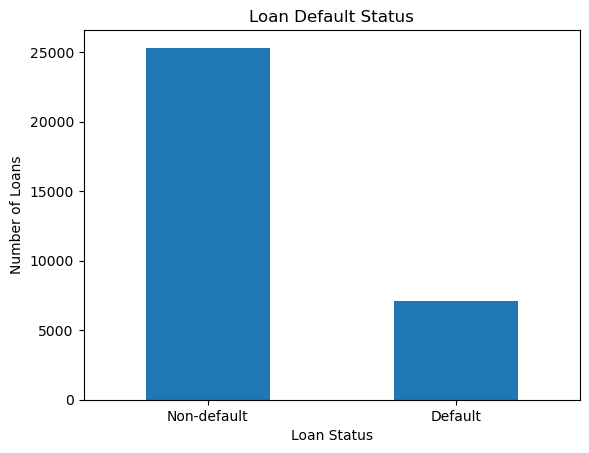

In [61]:
import matplotlib.pyplot as plt

df["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks([0, 1], ["Non-default", "Default"], rotation=0)
plt.show()

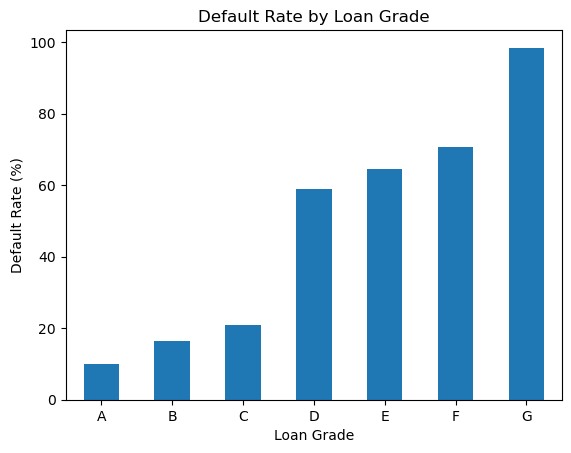

In [63]:
df.groupby("loan_grade")["loan_status"].mean().mul(100).plot(kind="bar")

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

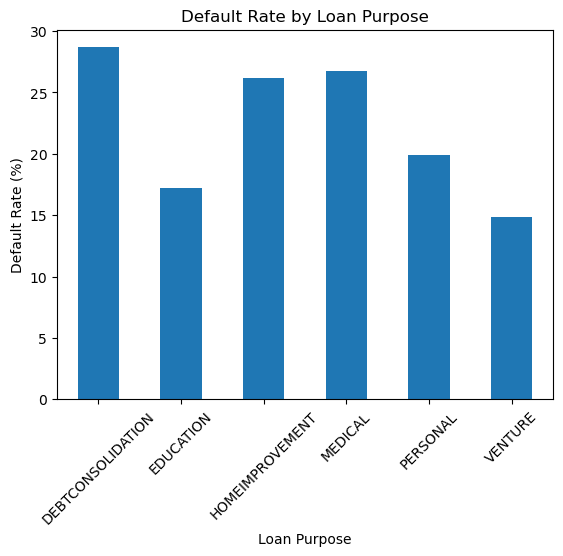

In [65]:
df.groupby("loan_intent")["loan_status"].mean().mul(100).plot(kind="bar")

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.show()

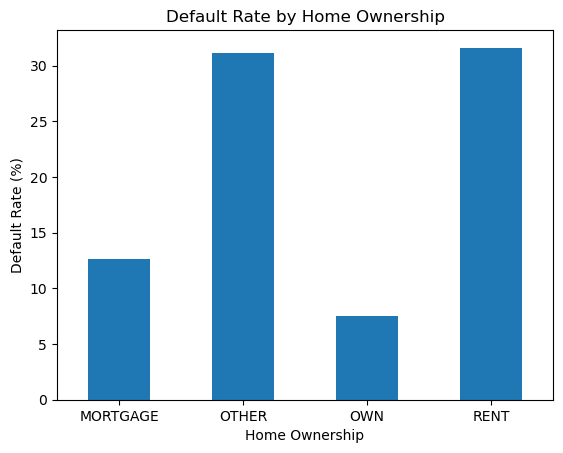

In [67]:
df.groupby("person_home_ownership")["loan_status"].mean().mul(100).plot(kind="bar")

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

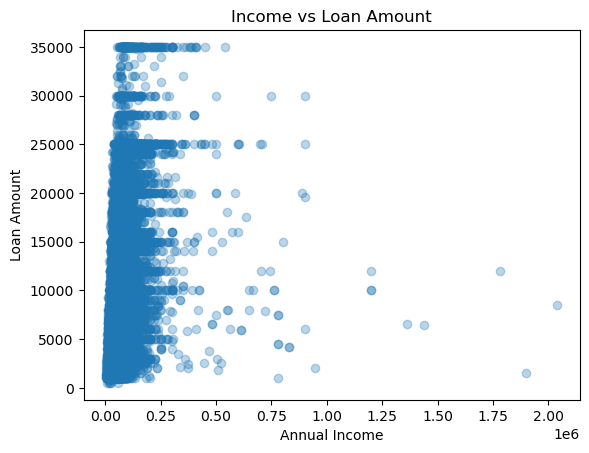

In [69]:
plt.scatter(df["person_income"], df["loan_amnt"], alpha=0.3)

plt.title("Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

In [71]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.141025,0.171634,0.051947,0.010846,-0.021517,-0.041745,0.878568
person_income,0.141025,1.000000,0.155088,0.316725,-0.000940,-0.169270,-0.294743,0.122798
person_emp_length,0.171634,0.155088,1.000000,0.111886,-0.053064,-0.085996,-0.058406,0.148280
loan_amnt,0.051947,0.316725,0.111886,1.000000,0.139592,0.105595,0.572659,0.042240
loan_int_rate,0.010846,-0.000940,-0.053064,0.139592,1.000000,0.320031,0.114301,0.015130
loan_status,-0.021517,-0.169270,-0.085996,0.105595,0.320031,1.000000,0.379596,-0.016294
loan_percent_income,-0.041745,-0.294743,-0.058406,0.572659,0.114301,0.379596,1.000000,-0.031310
cb_person_cred_hist_length,0.878568,0.122798,0.148280,0.042240,0.015130,-0.016294,-0.031310,1.000000


In [73]:
print("KEY FINDINGS")
print("-" * 40)

print(f"Total loans analyzed: {len(df):,}")
print(f"Overall default rate: {default_rate:.2f}%")
print("Highest default rate by loan grade: G")
print("Highest default rate by loan purpose: DEBTCONSOLIDATION")
print("Highest default rate by home ownership: RENT")
print("Highest default rate by income group: Below 30K")
print("Highest default rate by loan amount group: 20K-30K")
print("Highest default rate by previous default history: Yes")

KEY FINDINGS
----------------------------------------
Total loans analyzed: 32,407
Overall default rate: 21.87%
Highest default rate by loan grade: G
Highest default rate by loan purpose: DEBTCONSOLIDATION
Highest default rate by home ownership: RENT
Highest default rate by income group: Below 30K
Highest default rate by loan amount group: 20K-30K
Highest default rate by previous default history: Yes


In [75]:
df.to_csv("credit_risk_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
